# Lab 7 — Régression linéaire avec descente de gradient

## Objectifs

Dans ce notebook, nous allons :

- construire un petit jeu de données reproductible ;
- représenter une droite par ses paramètres $\beta_0$ et $\beta_1$ (les paramètres peuvent changés de noms cela le domaine beta => 'domaine du statistique' , si je ne me trompe pas pour machine learning et apprentissage automatique c'est plus w  ;
- mesurer l'erreur avec l'erreur quadratique moyenne ;
- calculer le gradient de cette erreur ;
- apprendre les paramètres avec la descente de gradient ;
- visualiser simultanément la droite et la trajectoire des paramètres ;
- comparer le résultat avec la solution analytique.

## 1. Le problème de régression

Nous possédons des observations $(x_i,y_i)$ et nous cherchons une droite qui prédit $y_i$ à partir de $x_i$.

Le modèle est :

$$
\widehat y_i = \beta_0 + \beta_1x_i.
$$

- $\widehat y_i$ : valeur prédite ;
- $\beta_0$ : ordonnée à l'origine de la droite ;
- $\beta_1$ : pente de la droite ;
- $x_i$ : variable explicative.

L'apprentissage consiste à trouver les valeurs de $\beta_0$ et $\beta_1$ qui donnent les meilleures prédictions.

## 2. Importer les bibliothèques

Nous utilisons seulement NumPy et Matplotlib.

Dépendances à installer si nécessaire :

```bash
python -m pip install numpy matplotlib
```

In [1]:
# NumPy réalise les calculs numériques sur les tableaux.
import numpy as np

# Matplotlib permet de construire les visualisations.
import matplotlib.pyplot as plt

## 3. Créer des données reproductibles

Nous simulons le modèle suivant :

$$
Y = 1.5 + 2.2X + \varepsilon,
$$

où $\varepsilon$ représente un bruit aléatoire. Ce bruit explique pourquoi les points ne sont pas exactement alignés.

Le générateur utilise une graine fixe : le notebook produit donc les mêmes observations à chaque exécution.

In [7]:
# Création d'un générateur aléatoire reproductible.
rng = np.random.default_rng(50)

# 100 valeurs régulièrement espacées entre -2.5 et 2.5.
x = np.linspace(-2.5, 2.5, 100)

# Paramètres utilisés uniquement pour simuler les données.
beta_0_reel = 1.5
beta_1_reel = 2.2

# Le bruit rend les observations plus réalistes.
bruit = rng.normal(loc=0.0, scale=0.8, size=x.size)
y = beta_0_reel + beta_1_reel * x + bruit

print("Nombre d'observations :", x.size)
print("Cinq premières valeurs de y :", np.round(y[:5], 3))

Nombre d'observations : 100
Cinq premières valeurs de y : [-3.611 -4.271 -3.242 -4.777 -2.223]


Résultat attendu : nous obtenons $50$ observations. Les cinq premières valeurs de $y$ commencent approximativement par $(-3.756,-4.607,-2.951,-2.574,-4.663)$.

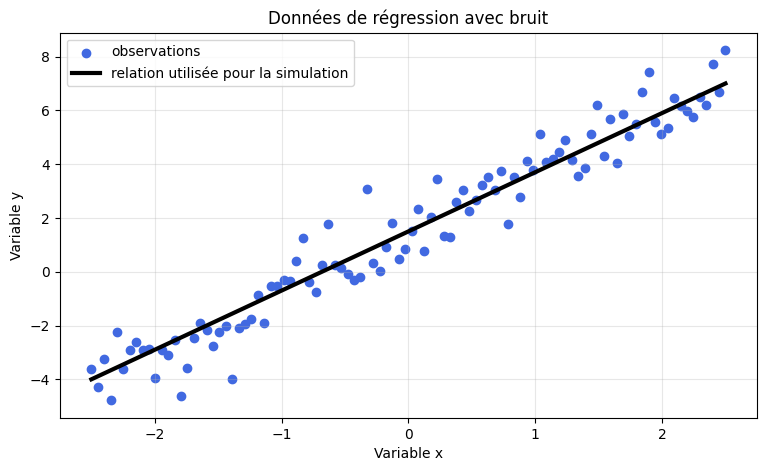

In [9]:
# Valeurs de la relation théorique avant l'ajout du bruit.
y_sans_bruit = beta_0_reel + beta_1_reel * x

plt.figure(figsize=(9, 5))
plt.scatter(x, y, color="royalblue", label="observations")
plt.plot(x, y_sans_bruit, color="black", linewidth=3,
         label="relation utilisée pour la simulation")
plt.xlabel("Variable x")
plt.ylabel("Variable y")
plt.title("Données de régression avec bruit")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

La ligne noire montre seulement comment les données ont été simulées. L'algorithme ne connaît ni cette ligne ni les paramètres réels. Il doit les estimer à partir des points bleus.

## 4. Définir le modèle, le coût et son gradient

Le résidu de l'observation $i$ est :

$$
e_i = \widehat y_i-y_i.
$$

Nous mesurons l'erreur totale avec la MSE :

$$
J(\beta_0,\beta_1)
=\frac{1}{n}\sum_{i=1}^{n}
(\beta_0+\beta_1x_i-y_i)^2.
$$

La MSE est toujours positive ou nulle. Elle pénalise fortement les grandes erreurs à cause du carré.

Son gradient est :

$$
\nabla J(\beta_0,\beta_1)=
\begin{pmatrix}
\dfrac{2}{n}\sum_{i=1}^{n}e_i \\
\dfrac{2}{n}\sum_{i=1}^{n}e_ix_i
\end{pmatrix}.
$$

In [10]:
def predire(x, beta_0, beta_1):
    """Calcule les prédictions de la droite beta_0 + beta_1*x."""
    return beta_0 + beta_1 * x


def erreur_quadratique_moyenne(y, y_pred):
    """Calcule la moyenne des carrés des résidus."""
    residus = y_pred - y
    return np.mean(residus ** 2)


def gradient_mse(x, y, beta_0, beta_1):
    """Calcule les deux dérivées partielles de la MSE."""
    y_pred = predire(x, beta_0, beta_1)
    residus = y_pred - y

    # Dérivée partielle du coût par rapport à beta_0.
    derivee_beta_0 = 2 * np.mean(residus)

    # Dérivée partielle du coût par rapport à beta_1.
    derivee_beta_1 = 2 * np.mean(residus * x)

    return np.array([derivee_beta_0, derivee_beta_1])

## 5. Calculer la première itération à la main

Nous partons de la droite horizontale $\widehat y=0$, donc :

$$
\beta_0^{(0)}=0, \qquad \beta_1^{(0)}=0.
$$

Avec un taux d'apprentissage $\alpha=0.1$, la mise à jour est :

$$
\boldsymbol\beta^{(1)}
=\boldsymbol\beta^{(0)}
-\alpha\nabla J(\boldsymbol\beta^{(0)}).
$$

In [11]:
# Paramètres de départ.
beta_depart = np.array([0.0, 0.0])
taux = 0.1

# Calcul du coût et du gradient au point de départ.
prediction_depart = predire(x, beta_depart[0], beta_depart[1])
cout_depart = erreur_quadratique_moyenne(y, prediction_depart)
gradient_depart = gradient_mse(x, y, beta_depart[0], beta_depart[1])

# Le signe moins nous déplace dans la direction opposée au gradient.
beta_apres_une_etape = beta_depart - taux * gradient_depart
prediction_etape_1 = predire(x, *beta_apres_une_etape)
cout_etape_1 = erreur_quadratique_moyenne(y, prediction_etape_1)

print("Gradient initial       :", np.round(gradient_depart, 4))
print("Nouveaux paramètres    :", np.round(beta_apres_une_etape, 4))
print(f"MSE avant la mise à jour : {cout_depart:.4f}")
print(f"MSE après la mise à jour : {cout_etape_1:.4f}")

Gradient initial       : [-2.9398 -9.7048]
Nouveaux paramètres    : [0.294  0.9705]
MSE avant la mise à jour : 13.8682
MSE après la mise à jour : 5.6738


Résultat attendu :

```text
Gradient initial       : [-2.93398 -9.7048]
Nouveaux paramètres    : [0.294 0.9705]
MSE avant la mise à jour : 13.8682
MSE après la mise à jour : 5.6738
```

Les composantes du gradient sont négatives. La direction de descente $-\nabla J$ est donc positive sur les deux axes : l'algorithme augmente l'ordonnée à l'origine et la pente. La MSE diminue dès la première étape.

## 6. Programmer la descente de gradient complète

À chaque itération, nous allons :

1. calculer les prédictions ;
2. mesurer la MSE ;
3. calculer le gradient ;
4. mettre à jour $\beta_0$ et $\beta_1$ ;
5. mémoriser la trajectoire pour la visualiser.

In [12]:
def descente_gradient_regression(
    x, y, beta_initial, taux=0.1, nombre_iterations=100
):
    """Apprend beta_0 et beta_1 en minimisant la MSE."""
    # La copie évite de modifier le tableau fourni à la fonction.
    beta = np.array(beta_initial, dtype=float).copy()

    historique_beta = []
    historique_cout = []

    # On conserve l'état initial et les états après chaque mise à jour.
    for iteration in range(nombre_iterations + 1):
        y_pred = predire(x, beta[0], beta[1])
        cout = erreur_quadratique_moyenne(y, y_pred)

        historique_beta.append(beta.copy())
        historique_cout.append(cout)

        # Aucun nouveau pas n'est nécessaire après le dernier état.
        if iteration < nombre_iterations:
            gradient = gradient_mse(x, y, beta[0], beta[1])
            beta = beta - taux * gradient

    return np.array(historique_beta), np.array(historique_cout)

In [13]:
# Lancement de l'apprentissage depuis beta_0 = beta_1 = 0.
historique_beta, historique_cout = descente_gradient_regression(
    x=x,
    y=y,
    beta_initial=[0.0, 0.0],
    taux=0.1,
    nombre_iterations=100,
)

beta_0_estime, beta_1_estime = historique_beta[-1]

print(f"beta_0 estimé : {beta_0_estime:.6f}")
print(f"beta_1 estimé : {beta_1_estime:.6f}")
print(f"MSE finale    : {historique_cout[-1]:.6f}")

beta_0 estimé : 1.469913
beta_1 estimé : 2.283024
MSE finale    : 0.629401


Résultat attendu :

```text
beta_0 estimé : 1.469913
beta_1 estimé : 2.283024
MSE finale    : 0.629401
```

Les estimations ne sont pas exactement $(1.5,2.2)$ à cause du bruit aléatoire. Elles sont toutefois proches des paramètres utilisés pour simuler les données.

## 7. Visualiser la droite apprise et les résidus

Un résidu est la distance verticale entre une observation et sa prédiction :

$$
e_i=\widehat y_i-y_i.
$$

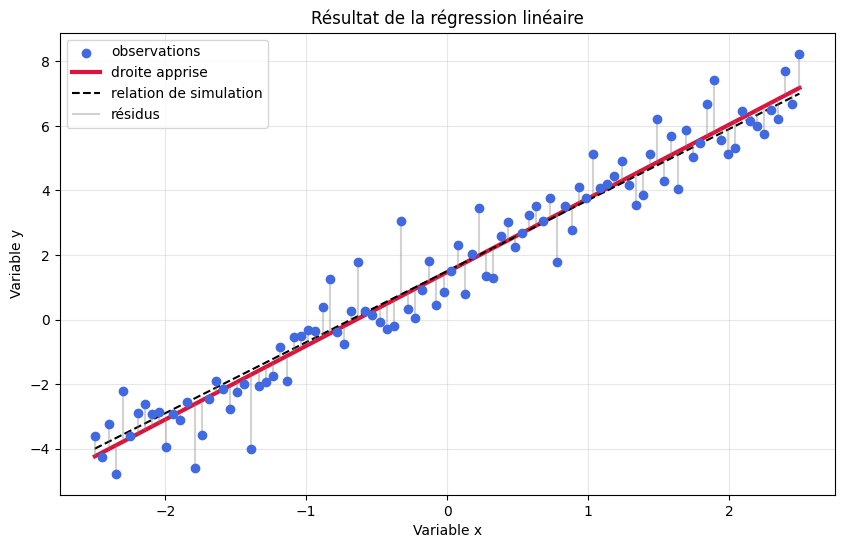

In [14]:
# Prédictions obtenues avec les paramètres finaux.
y_estime = predire(x, beta_0_estime, beta_1_estime)

plt.figure(figsize=(10, 6))
plt.scatter(x, y, color="royalblue", label="observations", zorder=3)
plt.plot(x, y_estime, color="crimson", linewidth=3,
         label="droite apprise")
plt.plot(x, y_sans_bruit, color="black", linestyle="--",
         label="relation de simulation")

# Chaque segment gris représente un résidu.
plt.vlines(x, y_estime, y, color="gray", alpha=0.35,
           label="résidus")

plt.xlabel("Variable x")
plt.ylabel("Variable y")
plt.title("Résultat de la régression linéaire")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

La droite rouge minimise la somme des carrés des segments gris. Elle ne doit pas nécessairement passer par tous les points : elle cherche un compromis global.

## 8. Voir la droite évoluer pendant l'apprentissage

Les six graphiques suivants correspondent à six moments de la même descente de gradient.

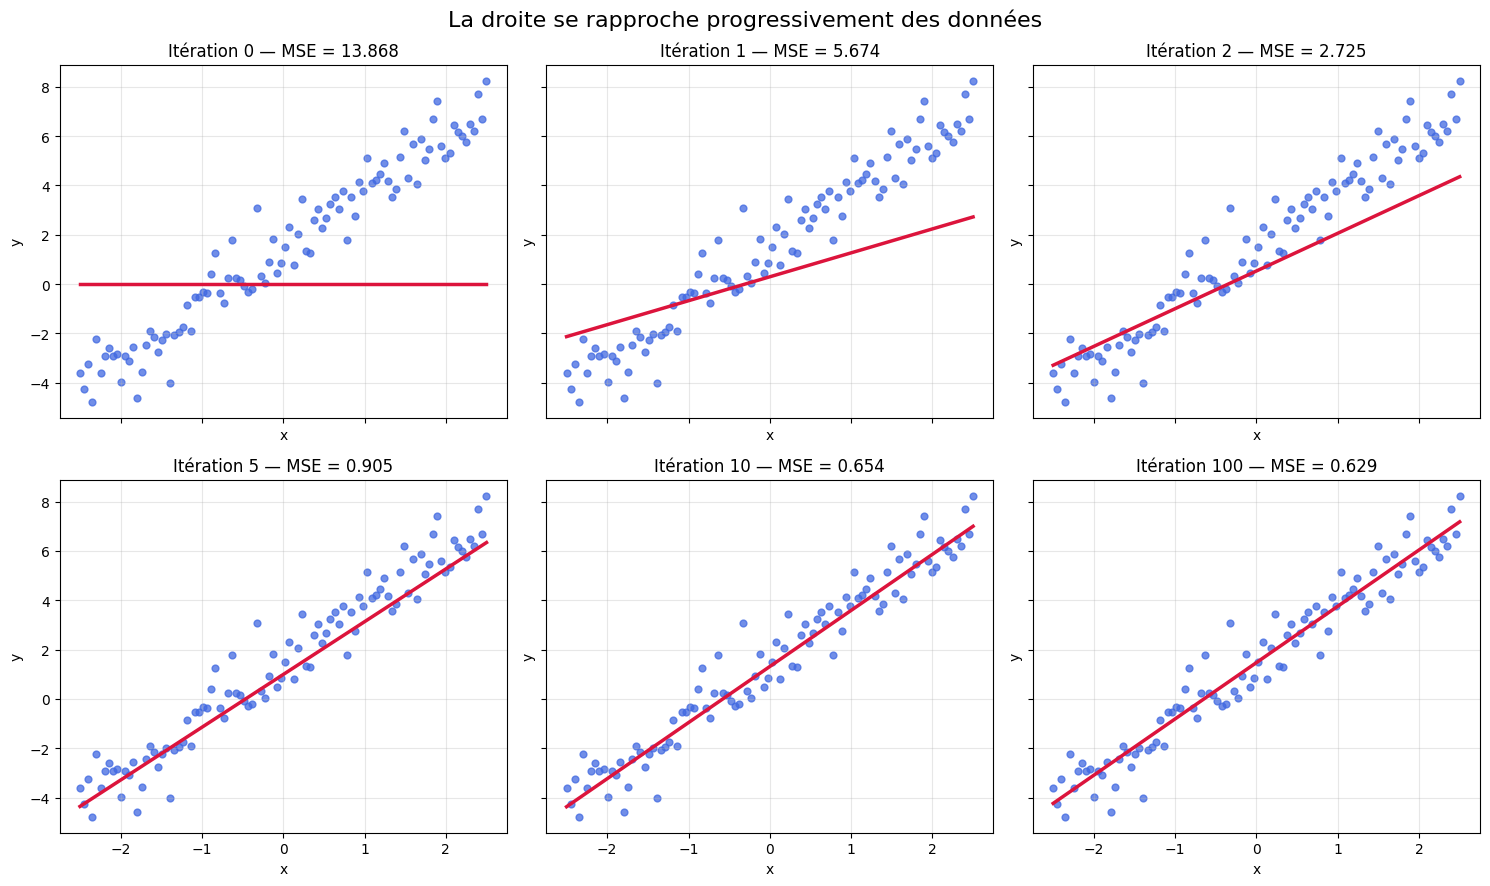

In [15]:
iterations_affichees = [0, 1, 2, 5, 10, 100]

fig, axes = plt.subplots(2, 3, figsize=(15, 9), sharex=True, sharey=True)

for axe, iteration in zip(axes.ravel(), iterations_affichees):
    beta_0_k, beta_1_k = historique_beta[iteration]
    y_k = predire(x, beta_0_k, beta_1_k)

    axe.scatter(x, y, color="royalblue", s=24, alpha=0.75)
    axe.plot(x, y_k, color="crimson", linewidth=2.5)
    axe.set_title(
        f"Itération {iteration} — MSE = {historique_cout[iteration]:.3f}"
    )
    axe.set_xlabel("x")
    axe.set_ylabel("y")
    axe.grid(alpha=0.3)

fig.suptitle("La droite se rapproche progressivement des données", fontsize=16)
fig.tight_layout()
plt.show()

À l'itération $0$, la prédiction est la droite $y=0$. Les premières corrections sont importantes, puis deviennent de plus en plus petites lorsque le gradient se rapproche du vecteur nul.

## 9. Vérifier la convergence

Une bonne descente doit présenter deux comportements :

- la MSE diminue puis se stabilise ;
- les paramètres convergent vers des valeurs fixes.

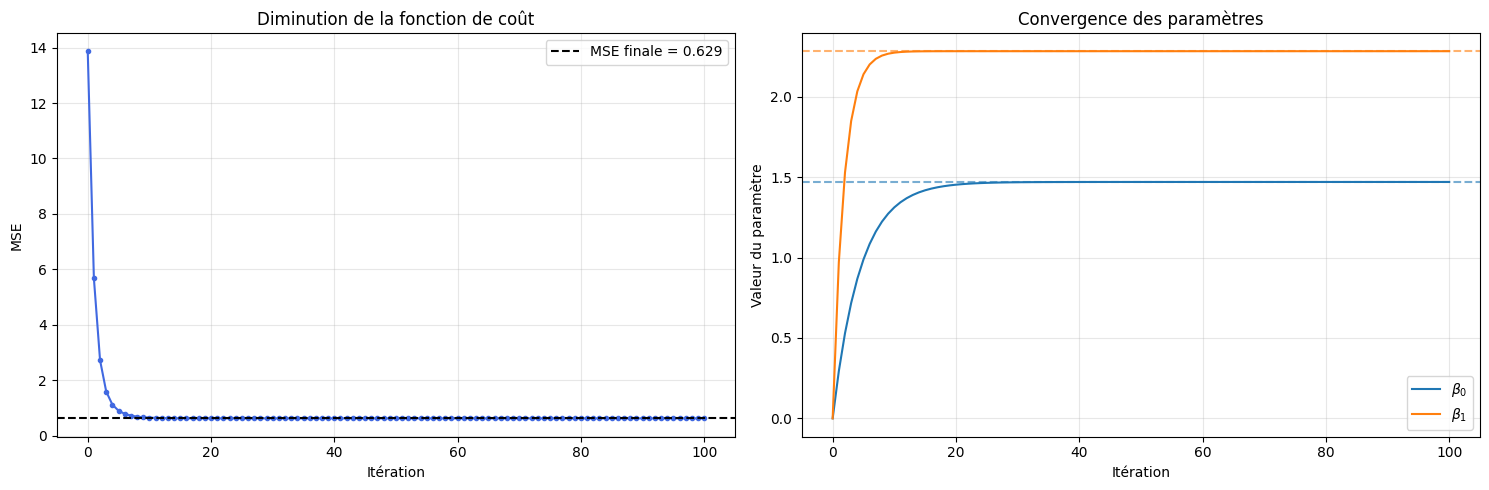

In [16]:
iterations = np.arange(historique_cout.size)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# À gauche : diminution de la fonction de coût.
axes[0].plot(iterations, historique_cout, color="royalblue", marker="o",
             markersize=3)
axes[0].axhline(historique_cout[-1], color="black", linestyle="--",
                label=f"MSE finale = {historique_cout[-1]:.3f}")
axes[0].set_xlabel("Itération")
axes[0].set_ylabel("MSE")
axes[0].set_title("Diminution de la fonction de coût")
axes[0].grid(alpha=0.3)
axes[0].legend()

# À droite : évolution séparée des deux paramètres.
axes[1].plot(iterations, historique_beta[:, 0], label=r"$\beta_0$")
axes[1].plot(iterations, historique_beta[:, 1], label=r"$\beta_1$")
axes[1].axhline(beta_0_estime, color="C0", linestyle="--", alpha=0.6)
axes[1].axhline(beta_1_estime, color="C1", linestyle="--", alpha=0.6)
axes[1].set_xlabel("Itération")
axes[1].set_ylabel("Valeur du paramètre")
axes[1].set_title("Convergence des paramètres")
axes[1].grid(alpha=0.3)
axes[1].legend()

fig.tight_layout()
plt.show()

## 10. Le paysage de la fonction de coût

Il faut distinguer deux espaces :

- le graphique des données utilise les axes $(x,y)$ ;
- l'optimisation utilise les axes $(\beta_0,\beta_1)$.

Chaque point du plan $(\beta_0,\beta_1)$ représente une droite différente. Sa hauteur est la MSE de cette droite. Pour une régression linéaire, ce paysage est une fonction convexe en forme de bol : elle possède un seul minimum global.

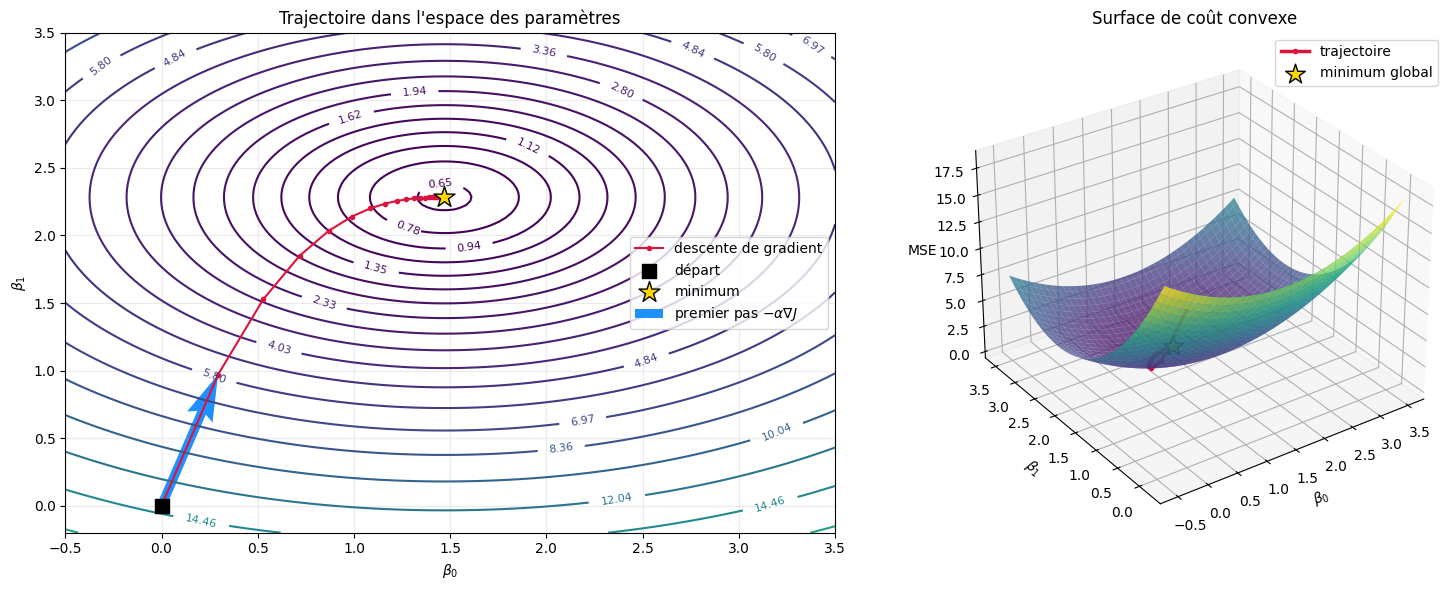

In [17]:
# Grille de paramètres possibles.
valeurs_beta_0 = np.linspace(-0.5, 3.5, 120)
valeurs_beta_1 = np.linspace(-0.2, 3.5, 120)
BETA_0, BETA_1 = np.meshgrid(valeurs_beta_0, valeurs_beta_1)

# Ajout d'un axe pour calculer les prédictions de toutes les droites.
predictions_grille = (
    BETA_0[..., np.newaxis] + BETA_1[..., np.newaxis] * x
)
COUT = np.mean((predictions_grille - y) ** 2, axis=-1)

fig = plt.figure(figsize=(16, 6))

# Courbes de niveau dans l'espace des paramètres.
axe_1 = fig.add_subplot(1, 2, 1)
niveaux = np.geomspace(historique_cout[-1] + 0.02, 30, 22)
contours = axe_1.contour(BETA_0, BETA_1, COUT, levels=niveaux, cmap="viridis")
axe_1.clabel(contours, inline=True, fontsize=8, fmt="%.2f")
axe_1.plot(historique_beta[:, 0], historique_beta[:, 1],
           color="crimson", marker="o", markersize=3,
           label="descente de gradient")
axe_1.scatter(*historique_beta[0], color="black", marker="s", s=90,
              label="départ", zorder=5)
axe_1.scatter(beta_0_estime, beta_1_estime, color="gold",
              edgecolor="black", marker="*", s=250,
              label="minimum", zorder=6)

# Flèche du premier déplacement : -alpha fois le gradient initial.
deplacement_initial = -taux * gradient_depart
axe_1.quiver(0, 0, deplacement_initial[0], deplacement_initial[1],
             angles="xy", scale_units="xy", scale=1, color="dodgerblue",
             width=0.012, label=r"premier pas $-\alpha\nabla J$")
axe_1.set_xlabel(r"$\beta_0$")
axe_1.set_ylabel(r"$\beta_1$")
axe_1.set_title("Trajectoire dans l'espace des paramètres")
axe_1.grid(alpha=0.25)
axe_1.legend()

# Surface 3D de la même fonction de coût.
axe_2 = fig.add_subplot(1, 2, 2, projection="3d")
axe_2.plot_surface(BETA_0, BETA_1, COUT, cmap="viridis",
                   alpha=0.75, edgecolor="none")
axe_2.plot(historique_beta[:, 0], historique_beta[:, 1], historique_cout,
           color="crimson", marker="o", markersize=3, linewidth=2.5,
           label="trajectoire")
axe_2.scatter(beta_0_estime, beta_1_estime, historique_cout[-1],
              color="gold", edgecolor="black", marker="*", s=220,
              label="minimum global")
axe_2.set_xlabel(r"$\beta_0$")
axe_2.set_ylabel(r"$\beta_1$")
axe_2.set_zlabel("MSE")
axe_2.set_title("Surface de coût convexe")
axe_2.view_init(elev=30, azim=-125)
axe_2.legend()

fig.tight_layout()
plt.show()

La trajectoire rouge ne déplace pas directement les points bleus du jeu de données. Elle déplace le couple $(\beta_0,\beta_1)$, donc elle transforme progressivement la droite de prédiction.

Comme la MSE de la régression linéaire est convexe, tout minimum local est également le minimum global. C'est une différence importante avec les fonctions non convexes étudiées dans le lab 2.

## 11. Comparer avec la solution analytique

La régression linéaire possède aussi une solution exacte. En écriture matricielle :

$$
\widehat{\boldsymbol\beta}
=(X^TX)^{-1}X^Ty.
$$

Dans le code, `np.linalg.solve` résout le système sans calculer explicitement l'inverse.

In [18]:
# La première colonne correspond à beta_0 et la seconde à beta_1.
matrice_X = np.column_stack((np.ones_like(x), x))

# Résolution des équations normales.
beta_analytique = np.linalg.solve(
    matrice_X.T @ matrice_X,
    matrice_X.T @ y,
)

print("Descente de gradient :", np.round(historique_beta[-1], 8))
print("Solution analytique  :", np.round(beta_analytique, 8))
print("Solutions proches    :",
      np.allclose(historique_beta[-1], beta_analytique, atol=1e-6))

Descente de gradient : [1.46991301 2.28302412]
Solution analytique  : [1.46991301 2.28302412]
Solutions proches    : True


Résultat attendu : `Solutions proches : True`. La descente de gradient retrouve numériquement la même solution que les équations normales.

Pour de très grands jeux de données ou des modèles plus complexes, une solution analytique peut être trop coûteuse ou inexistante. L'optimisation itérative devient alors essentielle.

## 12. Évaluer le modèle

Nous calculons deux mesures :

- la RMSE est la racine carrée de la MSE et s'exprime dans la même unité que $y$ ;
- $R^2$ mesure la proportion de variabilité expliquée par la droite.

In [19]:
# Racine de l'erreur quadratique moyenne.
rmse = np.sqrt(erreur_quadratique_moyenne(y, y_estime))

# Comparaison avec une prédiction constante égale à la moyenne de y.
somme_carres_residus = np.sum((y - y_estime) ** 2)
somme_carres_totale = np.sum((y - np.mean(y)) ** 2)
r2 = 1 - somme_carres_residus / somme_carres_totale

print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

RMSE : 0.7933
R²   : 0.9462


Résultat attendu : une RMSE proche de $0.7933$ et un $R^2$ proche de $0.9462$. Sur ces données simulées, la relation linéaire explique donc environ $94.6\%$ de la variabilité observée.

## 13. Lien avec le machine learning

Ce lab contient déjà les composants fondamentaux d'un algorithme supervisé :

| Composant | Dans ce notebook |
|---|---|
| Données d'entrée | $x_i$ |
| Cibles | $y_i$ |
| Modèle | $\widehat y_i=\beta_0+\beta_1x_i$ |
| Paramètres appris | $\beta_0,\beta_1$ |
| Fonction de perte | MSE |
| Algorithme d'optimisation | descente de gradient |

Dans un réseau de neurones, le modèle contient beaucoup plus de paramètres, mais l'idée reste la même : calculer une perte, obtenir son gradient, puis modifier les paramètres pour réduire cette perte.

## 14. Exercice progressif

1. Remplace le taux d'apprentissage $0.1$ successivement par $0.02$, $0.3$ et $0.5$.
2. Pour chaque taux, affiche la courbe de la MSE.
3. Compare la vitesse de convergence et indique si la méthode converge ou diverge.
4. Change le point initial en $(\beta_0,\beta_1)=(-2,3)$. Vérifie que la méthode atteint encore le même minimum.
5. Ajoute une observation aberrante avec une très grande valeur de $y$, puis observe la modification de la droite.

### Question d'interprétation

Pourquoi une observation aberrante influence-t-elle fortement une fonction de coût qui utilise le carré des résidus ?

### Vérification

Ta solution est cohérente si :

- le taux $0.02$ converge plus lentement que $0.1$ ;
- un taux trop grand produit des oscillations ou une divergence ;
- différents points initiaux convergent vers le même minimum lorsque le taux est adapté ;
- l'observation aberrante attire visiblement la droite vers elle.

## Conclusion

La régression linéaire transforme un problème de prédiction en problème d'optimisation. La descente de gradient ne déplace pas directement les observations : elle recherche dans l'espace des paramètres la droite qui minimise la MSE.

Dans ce cas, la fonction de coût est convexe. La trajectoire converge donc vers un minimum global lorsque le taux d'apprentissage est correctement choisi.